In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
import scipy.constants as sc

In [ ]:
# experimental parameters

N = 135
R = 27.5e-2     # 27.5cm
h = 14.25e-2    # 14.25cm
z = 0
I_85_theory = 1/2 # theoretical nuclear spin of Rb85

In [34]:
filename = 'opt - Rb 85, +.csv'
cols = (0, 7, 8)

data = np.genfromtxt(filename, delimiter=',', skip_header=1, usecols=cols, filling_values=np.nan)

freq_MHz, current, current_err = data.T

print(current_err)

[0.001465 0.004415 0.007635 0.00104  0.005445 0.00426  0.00525  0.013335
 0.00638  0.007055 0.01523 ]


In [35]:
# def freq_vs_I(current, I, N, R, h, z, B_amb):

#     """
#     Inputs:
#     current = current in coil (A)
#     I = nuclear spin
#     N = number of turns in coil
#     R = radius of coil
#     h = vertical distance between coils
#     z = vertical distance from midpoint between coils
#     B_amb = ambient magnetic field (Gauss)

#     Returns:
#     f = frequency (MHz)
#     """

#     f = (2.799/(2*I+1)) * (sc.mu_0*N*R**2/((h-z)**2 + R**2)**(3/2)) * current + (2.799/(2*I+1))*B_amb

#     return f


def freq_vs_I(current, I, N, R, h, z, B_amb):
    """
    Inputs:
    current = current in coil (A)
    I = nuclear spin
    N = number of turns in coil
    R = radius of coil
    h = vertical distance between coils
    z = vertical distance from midpoint between coils
    B_amb = ambient magnetic field (Gauss)

    Returns:
    f = frequency (MHz)
    """

    B_coil_T = sc.mu_0 * N * R**2 / (((h - z)**2 + R**2)**1.5) * current
    B_coil_G = 1e4 * B_coil_T   # Tesla -> Gauss

    f = (2.799 / (2*I + 1)) * (B_coil_G + B_amb)
    return f


def freq_err_from_current_err(current_err, I, N, R, h, z):
    """
    Propagate uncertainty from current to frequency.

    Inputs:
    current_err = uncertainty in current (A)
    I = nuclear spin
    N = number of turns
    R = coil radius
    h = coil separation
    z = position offset

    Returns:
    freq_err = uncertainty in frequency (MHz)
    """

    slope_T_per_A = sc.mu_0 * N * R**2 / (((h - z)**2 + R**2)**1.5)
    slope_G_per_A = 1e4 * slope_T_per_A
    slope_MHz_per_A = (2.799 / (2*I + 1)) * slope_G_per_A
    
    return np.abs(slope_MHz_per_A) * current_err



def I_nuc(m, N, R, h, z):

    """
    Inputs:
    m = slope of graph of frequency (MHz) vs current (A) in units of MHz/A
    N = number of turns in coil
    R = radius of coil
    h = vertical distance between coils
    z = vertical distance from midpoint between coils

    Returns:
    I = nuclear spin
    """

    return 0.5 * (2.799/m * (sc.mu_0*N*R**2/((h-z)**2 + R**2)**(3/2)) - 1)
    

def B_amb(y_int, I):

    """
    Inputs:
    y_int = y-intercept of graph of frequency (MHz) vs current (A)
    I = nuclear spin

    Returns:
    B_amb = ambient magnetic field (Gauss)
    """

    return y_int/(2.799/(2*I+1))


[0.00885277 0.02667918 0.04613715 0.00628456 0.03290331 0.02574254
 0.03172496 0.0805814  0.03855338 0.0426323  0.0920326 ]


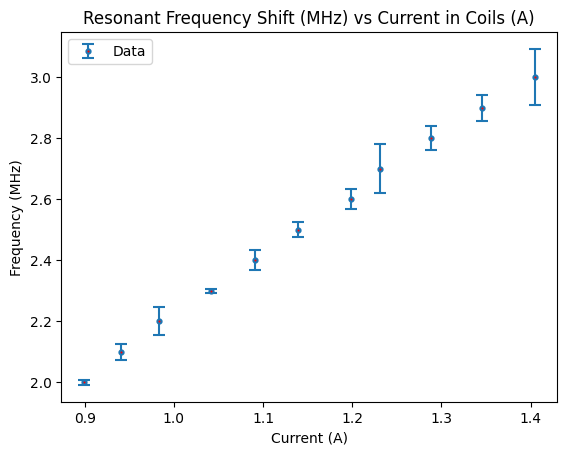

In [36]:
freq_err = freq_err_from_current_err(current_err, I_85_theory, N, R, h, z)

print(freq_err)

plt.errorbar(current, freq_MHz, 
                yerr=freq_err, 
                fmt='.',
                linestyle='none',
                capsize=4, 
                markerfacecolor='red',
                markeredgewidth=1.5,
                elinewidth=1.5, label='Data')
plt.ylabel(f"Frequency (MHz)")
plt.xlabel(f"Current (A)")
plt.title(f"Resonant Frequency Shift (MHz) vs Current in Coils (A)")
plt.legend()
plt.show()

Weighted linear fit results
  slope      = 2.0467 ± 0.0503 MHz/A
  intercept  = 0.1650 ± 0.0512 MHz
  chi^2      = 1.589
  dof        = 9
  chi^2/dof  = 0.177
  p-value    = 0.9964


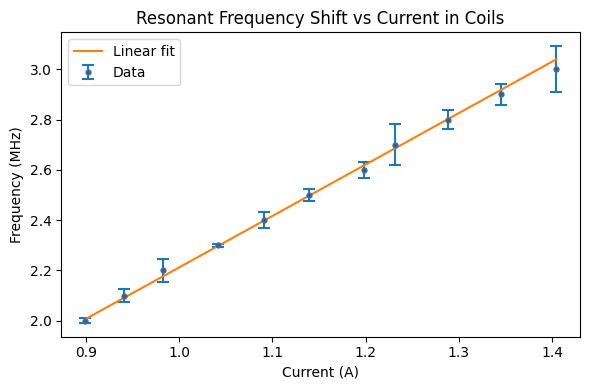

In [40]:
def linear_model(x, m, c):
    return m * x + c

p0 = [0.2, 0.02]

# weighted fit
popt1, pcov1 = curve_fit(
    linear_model,
    current,
    freq_MHz,
    p0=p0,
    sigma=freq_err,
    absolute_sigma=True   # use this if freq_err are actual 1-sigma uncertainties
)

slope_fit, yint_fit = popt1
slope_err, yint_err = np.sqrt(np.diag(pcov1))

# fitted values and residuals
freq_fit = linear_model(current, slope_fit, yint_fit)
residuals = freq_MHz - freq_fit

# chi^2
chi2_val = np.sum((residuals / freq_err)**2)

# degrees of freedom = n_data - n_params
ndof = len(freq_MHz) - len(popt1)

# reduced chi^2
chi2_red = chi2_val / ndof

# p-value: probability of getting chi^2 this large or larger
p_val = chi2.sf(chi2_val, ndof)

print("Weighted linear fit results")
print(f"  slope      = {slope_fit:.4f} ± {slope_err:.4f} MHz/A")
print(f"  intercept  = {yint_fit:.4f} ± {yint_err:.4f} MHz")
print(f"  chi^2      = {chi2_val:.3f}")
print(f"  dof        = {ndof:d}")
print(f"  chi^2/dof  = {chi2_red:.3f}")
print(f"  p-value    = {p_val:.4g}")

plt.figure(figsize=(6, 4))

plt.errorbar(current, freq_MHz, 
                yerr=freq_err, 
                fmt='.',
                linestyle='none',
                capsize=4, 
                markerfacecolor='red',
                markeredgewidth=1.5,
                elinewidth=1.5, label='Data')

x_plot = np.linspace(np.min(current), np.max(current), 300)
plt.plot(x_plot, linear_model(x_plot, slope_fit, yint_fit), label='Linear fit')

plt.xlabel("Current (A)")
plt.ylabel("Frequency (MHz)")
plt.title("Resonant Frequency Shift vs Current in Coils")
plt.legend()
plt.tight_layout()
plt.show()

The reduced $\chi^2$ was found to be significantly less than 1 ($\chi^2=0.177$), so the assigned uncertainties are likely overestimated. This suggests that the propagated uncertainties from the current do not accurately reflect the statistical scatter of the measured frequencies. Therefore, the uncertainty was instead estimated from the residuals of the fit, assuming uniform statistical scatter about the model.

Initial weighted fit
  slope      = 2.0467 ± 0.0503 MHz/A
  intercept  = 0.1650 ± 0.0512 MHz
  chi^2      = 1.589
  dof        = 9
  chi^2/dof  = 0.177
  p-value    = 0.9964

Rescaled-error fit
  scale factor = 0.4202
  slope        = 2.0467 ± 0.0211 MHz/A
  intercept    = 0.1650 ± 0.0215 MHz
  chi^2        = 9.000
  dof          = 9
  chi^2/dof    = 1.000
  p-value      = 0.4373


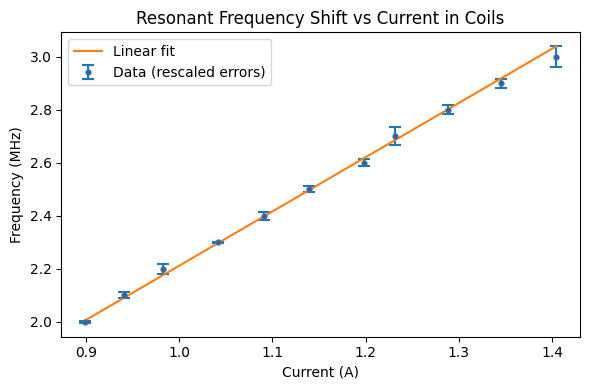

In [43]:

# first weighted fit
popt1, pcov1 = curve_fit(
    linear_model,
    current,
    freq_MHz,
    p0=p0,
    sigma=freq_err,
    absolute_sigma=True
)

slope_fit1, yint_fit1 = popt1
slope_err1, yint_err1 = np.sqrt(np.diag(pcov1))

freq_fit1 = linear_model(current, slope_fit1, yint_fit1)
residuals1 = freq_MHz - freq_fit1

chi2_val1 = np.sum((residuals1 / freq_err)**2)
ndof = len(freq_MHz) - len(popt1)
chi2_red1 = chi2_val1 / ndof
p_val1 = chi2.sf(chi2_val1, ndof)

print("Initial weighted fit")
print(f"  slope      = {slope_fit1:.4f} ± {slope_err1:.4f} MHz/A")
print(f"  intercept  = {yint_fit1:.4f} ± {yint_err1:.4f} MHz")
print(f"  chi^2      = {chi2_val1:.3f}")
print(f"  dof        = {ndof}")
print(f"  chi^2/dof  = {chi2_red1:.3f}")
print(f"  p-value    = {p_val1:.4g}")

# rescale error bars
scale = np.sqrt(chi2_red1)
freq_err_scaled = freq_err * scale

# refit using scaled errors
popt2, pcov2 = curve_fit(
    linear_model,
    current,
    freq_MHz,
    p0=p0,
    sigma=freq_err_scaled,
    absolute_sigma=True
)

slope_fit2, yint_fit2 = popt2
slope_err2, yint_err2 = np.sqrt(np.diag(pcov2))

freq_fit2 = linear_model(current, slope_fit2, yint_fit2)
residuals2 = freq_MHz - freq_fit2

chi2_val2 = np.sum((residuals2 / freq_err_scaled)**2)
chi2_red2 = chi2_val2 / ndof
p_val2 = chi2.sf(chi2_val2, ndof)

print("\nRescaled-error fit")
print(f"  scale factor = {scale:.4f}")
print(f"  slope        = {slope_fit2:.4f} ± {slope_err2:.4f} MHz/A")
print(f"  intercept    = {yint_fit2:.4f} ± {yint_err2:.4f} MHz")
print(f"  chi^2        = {chi2_val2:.3f}")
print(f"  dof          = {ndof}")
print(f"  chi^2/dof    = {chi2_red2:.3f}")
print(f"  p-value      = {p_val2:.4g}")



plt.figure(figsize=(6,4))

plt.errorbar(current, freq_MHz, 
                yerr=freq_err_scaled, 
                fmt='.',
                linestyle='none',
                capsize=4, 
                markerfacecolor='red',
                markeredgewidth=1.5,
                elinewidth=1.5, label='Data (rescaled errors)')

x_plot = np.linspace(np.min(current), np.max(current), 300)
plt.plot(x_plot, linear_model(x_plot, slope_fit2, yint_fit2), label='Linear fit')

plt.xlabel("Current (A)")
plt.ylabel("Frequency (MHz)")
plt.title("Resonant Frequency Shift vs Current in Coils")
plt.legend()

plt.tight_layout()
plt.show()

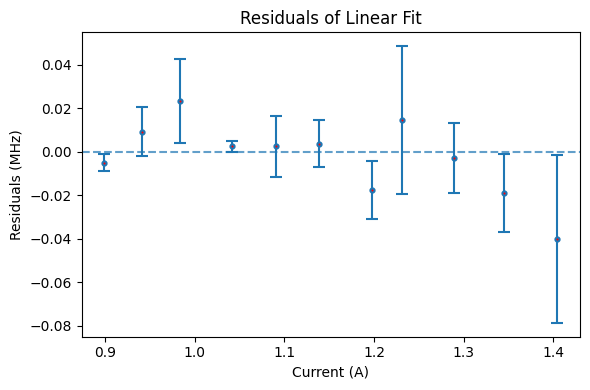

In [44]:
# compute residuals using final (rescaled) fit
freq_fit = linear_model(current, slope_fit2, yint_fit2)
residuals = freq_MHz - freq_fit

# --- residual plot ---
plt.figure(figsize=(6,4))

plt.errorbar(
    current,
    residuals,
    yerr=freq_err_scaled,   # same y-errors as your fit
    fmt='.',
    linestyle='none',
    markersize=6,
    markerfacecolor='red',
    markeredgewidth=1.5,
    capsize=4,
    elinewidth=1.5
)

plt.axhline(0, linestyle='--', alpha=0.7)  # zero line

plt.xlabel("Current (A)")
plt.ylabel("Residuals (MHz)")
plt.title("Residuals of Linear Fit")

plt.tight_layout()
plt.show()